In [159]:
# ===============================
# 1. Import libraries
# ===============================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import cross_val_score, TimeSeriesSplit, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet', quiet=True)

import warnings
warnings.filterwarnings('ignore')

SEED = 42

print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


In [160]:



# Project root (notebook is inside notebooks/)
PROJECT_ROOT = Path("..").resolve()

# Input files
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

# Output files
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SUBMISSION_PATH_050 = OUTPUT_DIR / "submission_threshold_050.csv"
SUBMISSION_PATH_072 = OUTPUT_DIR / "submission_threshold_072.csv"

# Load train data
df = pd.read_csv(TRAIN_PATH)

print("Train file:", TRAIN_PATH)
print("Test file:", TEST_PATH)
print("Output dir:", OUTPUT_DIR)

Train file: /Users/atulbharti/Downloads/Hertie_School_study_Docs/Semester_2/ML/homework-3-ab/data/train.csv
Test file: /Users/atulbharti/Downloads/Hertie_School_study_Docs/Semester_2/ML/homework-3-ab/data/test.csv
Output dir: /Users/atulbharti/Downloads/Hertie_School_study_Docs/Semester_2/ML/homework-3-ab/outputs


In [161]:
#loading the train.csv dataset

df = pd.read_csv("../data/train.csv")

df.head()

,Id,livestream_id,username,text,date,time,channelname,subscriber_bi,IS_TOXIC
0,12,1,admirallove,"""""jan 6th was a peaceful protest""""",2023-08-02,2023-08-02 18:47:46+00:00,sondsol,1.0,0
1,13,1,i8urmom2,"unprecedented? it was a """"mostly peaceful"""" riot.",2023-08-02,2023-08-02 18:47:53+00:00,sondsol,0.0,0
2,14,1,i8urmom2,"unprecedented riots are those left wing """"prot...",2023-08-02,2023-08-02 18:48:15+00:00,sondsol,0.0,0
3,15,1,i8urmom2,"@AdmiralLove it was, by far. far far far far f...",2023-08-02,2023-08-02 18:48:44+00:00,sondsol,0.0,0
4,16,1,internet_gas,The prosecutor was between 2015 to 2016 Zloche...,2023-08-02,2023-08-02 18:48:45+00:00,sondsol,0.0,0


In [162]:
#structure and preview
df.head()
df.shape

(119817, 9)

In [163]:
df.columns

Index(['Id', 'livestream_id', 'username', 'text', 'date', 'time',
       'channelname', 'subscriber_bi', 'IS_TOXIC'],
      dtype='str')

In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119817 entries, 0 to 119816
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Id             119817 non-null  int64  
 1   livestream_id  119817 non-null  int64  
 2   username       119817 non-null  str    
 3   text           119817 non-null  str    
 4   date           119817 non-null  str    
 5   time           119817 non-null  str    
 6   channelname    119817 non-null  str    
 7   subscriber_bi  119817 non-null  float64
 8   IS_TOXIC       119817 non-null  int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 19.6 MB


In [165]:
#missing values
df.isnull().values.any()

np.False_

In [166]:
df.describe(include="all")

,Id,livestream_id,username,text,date,time,channelname,subscriber_bi,IS_TOXIC
count,119817.000000,119817.000000,119817,119817,119817,119817,119817,119817.000000,119817.000000
unique,NaN,NaN,8632,97426,12,74135,41,NaN,NaN
top,NaN,NaN,nightbot,YEP,2023-08-04,2023-08-04 14:26:45+00:00,central_committee,NaN,NaN
freq,NaN,NaN,2178,908,27015,99,36694,NaN,NaN
mean,83978.135398,46.938798,NaN,NaN,NaN,NaN,NaN,0.658997,0.071810
std,48941.651932,28.201280,NaN,NaN,NaN,NaN,NaN,0.474048,0.258173
min,12.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,40722.000000,28.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,83197.000000,47.000000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
75%,126522.000000,65.000000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000


In [167]:
# Subset only toxic comments
toxic_df = df[df["IS_TOXIC"] == 1]

toxic_df.head()

,Id,livestream_id,username,text,date,time,channelname,subscriber_bi,IS_TOXIC
8,21,1,i8urmom2,who cares what motivated them...they were piec...,2023-08-02,2023-08-02 18:50:16+00:00,sondsol,0.0,1
9,22,1,fivetissimo,@internet_gas nuance is for bitches,2023-08-02,2023-08-02 18:50:35+00:00,sondsol,0.0,1
12,25,1,fivetissimo,@i8urmom2 nobody said that dickless LUL,2023-08-02,2023-08-02 18:51:00+00:00,sondsol,0.0,1
15,28,1,i8urmom2,@FiveTissimo youre projecting your anger and f...,2023-08-02,2023-08-02 18:52:15+00:00,sondsol,0.0,1
26,40,1,fivetissimo,"""""REEEEE blackblock is the ENTIRE leftwing"""" -...",2023-08-02,2023-08-02 18:54:28+00:00,sondsol,0.0,1


In [168]:
#Parsing date and time
df["time"] = pd.to_datetime(df["time"], errors="coerce")


df = df.sort_values("time").reset_index(drop=True)

print(df["time"].iloc[0], "to", df["time"].iloc[-1])

df.head()



2023-08-02 18:45:24+00:00 to 2023-09-11 23:36:07+00:00


,Id,livestream_id,username,text,date,time,channelname,subscriber_bi,IS_TOXIC
0,439,2,koshkathemerc,Ahhhhhh looks like I'm not collecting my bet t...,2023-08-02,2023-08-02 18:45:24+00:00,tyt,1.0,0
1,443,2,eurylino,She's the most disappointing Kraken of all tim...,2023-08-02,2023-08-02 18:45:24+00:00,tyt,1.0,0
2,440,2,hoosierdaddy89,Sickening Six,2023-08-02,2023-08-02 18:45:24+00:00,tyt,0.0,0
3,441,2,hoosierdaddy89,Like the Chicago 7,2023-08-02,2023-08-02 18:45:24+00:00,tyt,0.0,0
4,442,2,hoosierdaddy89,need a name,2023-08-02,2023-08-02 18:45:24+00:00,tyt,0.0,0


## Train/Validation Split
Splitting the data right now **before any feature engineering**, using 95/05 split. All feature engineering will then be fitted on the training set only, and applied to the validation and test set to avoid any form of **data leakage** where information from the test set influences how we build features. Because the data is ordered by time, we take the first 95% as training, the next 5% as validation. 


We split the data using `GroupShuffleSplit` based on `livestream_id`. This ensures that all comments from the same livestream session are assigned entirely to either the training set or the validation set, reducing leakage across splits.

This is important because comments within the same livestream can share common context, style, and discussion topics. A grouped split therefore gives a more realistic estimate of generalisation to unseen livestream sessions.

In [169]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(test_size=0.05, random_state=42)

train_indices, val_indices = next(
    splitter.split(df, groups=df["livestream_id"])
)

train_data = df.iloc[train_indices].copy()
validation_data = df.iloc[val_indices].copy()

y_train = train_data["IS_TOXIC"].values
y_validation = validation_data["IS_TOXIC"].values

print(f"Training samples:   {len(train_data):,}")
print(f"Validation samples: {len(validation_data):,}")
print()
print(f"Train date range: {train_data['time'].iloc[0].date()} to {train_data['time'].iloc[-1].date()}")
print(f"Val date range:   {validation_data['time'].iloc[0].date()} to {validation_data['time'].iloc[-1].date()}")

Training samples:   115,125
Validation samples: 4,692

Train date range: 2023-08-02 to 2023-09-11
Val date range:   2023-08-02 to 2023-09-06


## Part 1: Regex Feature Engineering

*Feature Engineering* is the process of creating new features from the existing ones. This can be applied to any data, but is particularly useful when data is not numerical. Text, image data, and audio data are all examples of data that can be feature engineered.

In our case, since we are working on the twitch comments, will have to convert raw text into feature that can be used to predict the toxicity. I will use '**Regex**

### A quick regex refresher

| Pattern | Matches |
|---|---|
| `[A-Z]` | any uppercase letter |
| `\w+` | one or more word characters |
| `\s+` | one or more whitespace characters |
| `https?://\S+` | a URL starting with http or https |
| `@\w+` | a Twitter @mention |
| `[!?]` | exclamation mark or question mark |

Below I have defined a function that when given a column of text will return a bunch of new features based on Regex patterns. I have added a few to start, see if you can add some of the ones we discussed.

Note: In python `re.findall(pattern, text)` returns a list of all matches so `len(re.findall(...))` gives us a count of matches.


In [170]:
def extract_regex_features(text_series):
    """
    Extract hand-crafted features from a pandas Series of tweet strings.
    Returns a DataFrame with one row per tweet and one column per feature.
    """
    features = pd.DataFrame()
    features['char_count'] = text_series.str.len() # This calulates the length of each twitch comment
    features['word_count'] = text_series.str.split().str.len() # This calculates the number of words in each twitch comment
    
    features['caps_ratio'] = text_series.apply(
        lambda t: len(re.findall(r'[A-Z]', t)) / max(len(re.findall(r'[a-zA-Z]', t)), 1)
    )  # This calculates the ratio of uppercase characters to total characters
    
    features['exclamation_count'] = text_series.apply(lambda t: len(re.findall(r'!', t))) # This calculates the number of exclamation marks
    features['question_count']    = text_series.apply(lambda t: len(re.findall(r'\?', t))) # This calculates the number of question marks
    features['has_url']           = text_series.apply(
        lambda t: int(bool(re.search(r'https?://\S+|www\.\S+', t))) # This checks if the tweet contains a URL
    )
    
    features['mention_count']  = text_series.apply(lambda t: len(re.findall(r'@\w+', t))) # This calculates the number of mentions
    features['hashtag_count']  = text_series.apply(lambda t: len(re.findall(r'#\w+', t))) # This calculates the number of hashtags
    features['repeated_chars'] = text_series.apply(
        lambda t: int(bool(re.search(r'(.)\1{2,}', t))) # This checks if the tweet contains a character repeated more than twice
    )
    return features

# Apply to all four splits
X_regex_train = extract_regex_features(train_data['text'])
X_regex_val   = extract_regex_features(validation_data['text'])

X_regex_train.head(20)

,char_count,word_count,caps_ratio,exclamation_count,question_count,has_url,mention_count,hashtag_count,repeated_chars
0,52,9,0.046512,0,0,0,0,0,1
1,108,19,0.046512,0,0,0,0,0,0
2,13,2,0.166667,0,0,0,0,0,0
3,18,4,0.142857,0,0,0,0,0,0
4,11,3,0.000000,0,0,0,0,0,0
5,149,25,0.016529,1,0,0,0,0,0
6,12,2,0.222222,0,0,0,0,0,0
7,63,9,0.020408,3,0,0,1,0,1
8,26,4,0.100000,0,0,0,0,0,0
9,67,17,0.060000,0,0,0,0,0,0


In [171]:
X_regex_train.shape
X_regex_val.shape

(4692, 9)

In [172]:
X_regex_train.columns

Index(['char_count', 'word_count', 'caps_ratio', 'exclamation_count',
       'question_count', 'has_url', 'mention_count', 'hashtag_count',
       'repeated_chars'],
      dtype='str')

In [173]:
X_regex_train.isnull().sum()

char_count           0
word_count           0
caps_ratio           0
exclamation_count    0
question_count       0
has_url              0
mention_count        0
hashtag_count        0
repeated_chars       0
dtype: int64

In [174]:
X_regex_train.describe()

,char_count,word_count,caps_ratio,exclamation_count,question_count,has_url,mention_count,hashtag_count,repeated_chars
count,115125.000000,115125.000000,115125.000000,115125.000000,115125.000000,115125.000000,115125.000000,115125.000000,115125.000000
mean,41.464773,7.139987,0.182114,0.082154,0.107474,0.022046,0.110680,0.001416,0.064052
std,42.492371,7.242803,0.291628,0.535597,0.443179,0.146832,0.319253,0.050083,0.244847
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,2.000000,0.013889,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,5.000000,0.062500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,54.000000,9.000000,0.168831,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,515.000000,102.000000,1.000000,54.000000,29.000000,1.000000,6.000000,9.000000,1.000000


In [175]:
#check if any of these features differ meaningfully between toxic and non-toxic comments in teh training set 
regex_with_target = X_regex_train.copy()
regex_with_target["IS_TOXIC"] = y_train

# Group by toxicity and take mean
regex_with_target.groupby("IS_TOXIC").mean()

,char_count,word_count,caps_ratio,exclamation_count,question_count,has_url,mention_count,hashtag_count,repeated_chars
IS_TOXIC,,,,,,,,,
0,40.448165,6.910524,0.186234,0.081158,0.108572,0.023597,0.110827,0.001497,0.063979
1,54.639627,10.113738,0.128715,0.095065,0.093246,0.001940,0.108767,0.000364,0.064993


## Part 2: Datetime Feature Engineering

Chat behavior on livestream platforms like Twitch can vary depending on when comments are posted. For example, users may behave differently late at night compared to during the day, or on weekends compared to weekdays.

However, the raw `time` column is not directly useful for machine learning, since each timestamp is unique and cannot be interpreted numerically by the model.

To make this information usable, we extract meaningful components from the timestamp.

### Why I am doing this

We extract datetime features for three main reasons:

1. **Capture behavioral patterns over time**  
   Toxicity may vary by hour of day or day of week.

2. **Reduce complexity of raw timestamps**  
   Instead of using full timestamps, we extract interpretable features like hour and weekday.

3. **Provide additional signals beyond text**  
   These features complement text-based features (TF-IDF) by adding contextual information.

The features we extract are:
- **hour**: hour of the day (0–23)
- **dayofweek**: day of the week (0 = Monday, 6 = Sunday)
- **is_weekend**: whether the comment was posted on a weekend

In [176]:
# First ensure time is datetime
train_data["time"] = pd.to_datetime(train_data["time"], errors="coerce")
validation_data["time"] = pd.to_datetime(validation_data["time"], errors="coerce")

# Extract features directly into dataset
for df_split in [train_data, validation_data]:
    df_split["hour"] = df_split["time"].dt.hour
    df_split["day_of_week"] = df_split["time"].dt.dayofweek
    df_split["is_weekend"] = df_split["day_of_week"].isin([5, 6]).astype(int)

In [177]:
#check if it worked
train_data[["time", "hour", "day_of_week", "is_weekend"]].head()

,time,hour,day_of_week,is_weekend
0,2023-08-02 18:45:24+00:00,18,2,0
1,2023-08-02 18:45:24+00:00,18,2,0
2,2023-08-02 18:45:24+00:00,18,2,0
3,2023-08-02 18:45:24+00:00,18,2,0
4,2023-08-02 18:45:24+00:00,18,2,0


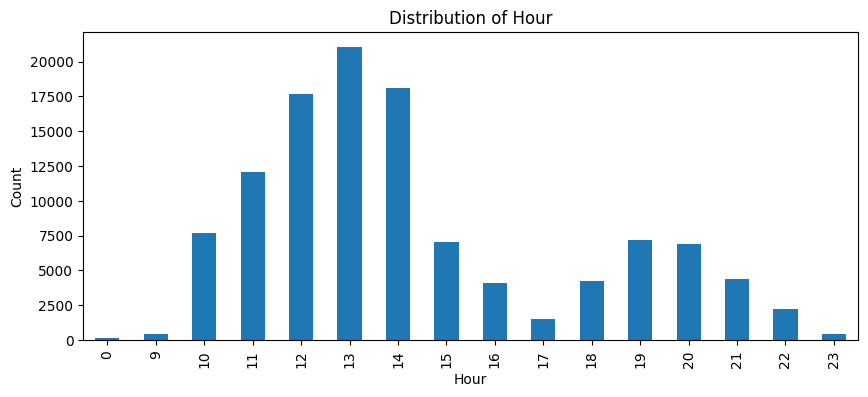

In [178]:
train_data["hour"].value_counts().sort_index().plot(kind="bar", figsize=(10,4))
plt.title("Distribution of Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

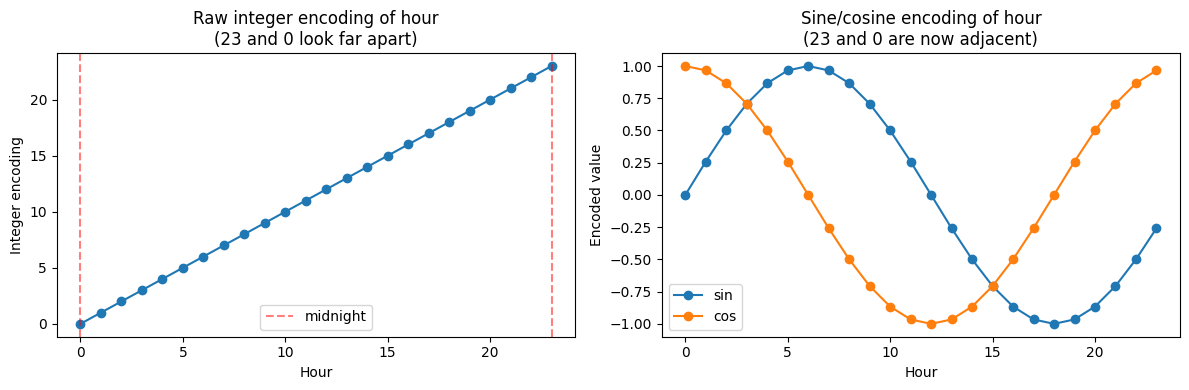

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hours = np.arange(24)
axes[0].plot(hours, hours, marker='o')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Integer encoding')
axes[0].set_title('Raw integer encoding of hour\n(23 and 0 look far apart)')
axes[0].axvline(x=0,  color='red', linestyle='--', alpha=0.5, label='midnight')
axes[0].axvline(x=23, color='red', linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(hours, np.sin(2 * np.pi * hours / 24), marker='o', label='sin')
axes[1].plot(hours, np.cos(2 * np.pi * hours / 24), marker='o', label='cos')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Encoded value')
axes[1].set_title('Sine/cosine encoding of hour\n(23 and 0 are now adjacent)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Sine/cosine (cyclical) encoding

The solution is to encode cyclical variables using sine and cosine. For a variable with period $T$:

$$\text{sin\_enc} = \sin\left(\frac{2\pi \cdot x}{T}\right), \quad \text{cos\_enc} = \cos\left(\frac{2\pi \cdot x}{T}\right)$$

Together, these two values uniquely identify any point in the cycle, and points that are close in time are also close in the encoded space. Note that you always need **both** sin and cos as neither alone is sufficient to uniquely identify a time (e.g. sin gives the same value for hour 2 and hour 10). Use the equations above to fill in the blanks in the function below. Then apply the encoding to the data, storing the result in `train_data`, and `validation_data`.

In [180]:
def add_cyclical_features(df_in):
    out = pd.DataFrame(index=df_in.index)
    
    out['hour_sin'] = np.sin(2 * np.pi * df_in['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * df_in['hour'] / 24)
    out['dow_sin']  = np.sin(2 * np.pi * df_in['day_of_week'] / 7)
    out['dow_cos']  = np.cos(2 * np.pi * df_in['day_of_week'] / 7)
    out["is_weekend"] = df_in["is_weekend"]
    
    return out

X_dt_train = add_cyclical_features(train_data)
X_dt_val   = add_cyclical_features(validation_data)

X_dt_train.head()

,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend
0,-1.0,-1.836970e-16,0.974928,-0.222521,0
1,-1.0,-1.836970e-16,0.974928,-0.222521,0
2,-1.0,-1.836970e-16,0.974928,-0.222521,0
3,-1.0,-1.836970e-16,0.974928,-0.222521,0
4,-1.0,-1.836970e-16,0.974928,-0.222521,0


In [181]:
X_dt_val.head()

,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend
38,-1.0,-1.836970e-16,0.974928,-0.222521,0
39,-1.0,-1.836970e-16,0.974928,-0.222521,0
46,-1.0,-1.836970e-16,0.974928,-0.222521,0
52,-1.0,-1.836970e-16,0.974928,-0.222521,0
53,-1.0,-1.836970e-16,0.974928,-0.222521,0


## Part 3: Text Preprocessing and TF-IDF

Our regex-based features gave us a useful starting point, but they only capture a limited part of the information in the text. In a text classification problem, the actual words and short phrases used in a comment are often much more informative.

To make use of this, we apply a standard NLP technique called **TF-IDF**. TF-IDF converts text into numerical features by representing each comment as a weighted combination of words and phrases. This allows the model to learn which terms are more associated with toxic versus non-toxic comments.

Before vectorising the text, we apply some light preprocessing. Twitch comments may contain URLs, mentions, repeated characters, punctuation, and other noisy elements. Some cleaning helps reduce unnecessary variation in the text while keeping the main signal intact.

### Why we are doing this

We do this for three reasons:

1. **Machine learning models cannot use raw text directly**  
   The text column must first be converted into numbers.

2. **We want to capture the meaning and content of comments**  
   Unlike regex features, TF-IDF uses the full vocabulary of the corpus.

3. **We want to reduce noisy variation in the text**  
   Simple normalization helps the model treat similar comments more consistently.

In this notebook, we use a light preprocessing strategy so that we do not remove too much Twitch-specific signal.

In [182]:


# make sure nltk wordnet is installed (run once)
# import nltk
# nltk.download('wordnet')
# nltk.download('omw-1.4')

STOPWORDS = {
    'a','about','above','after','again','all','am','an','and','any','are','as','at',
    'be','because','been','before','being','below','between','both','by','can','did',
    'do','does','doing','down','during','each','few','for','from','further','had',
    'has','have','having','he','her','here','hers','herself','him','himself','his',
    'how','i','if','in','into','is','it','its','itself','just','me','more','most',
    'my','myself','now','of','on','once','only','or','other','our','ours','ourselves',
    'out','own','same','she','should','so','some','such','than','that','the','their',
    'theirs','them','themselves','then','there','these','they','this','those','through',
    'to','too','under','until','up','very','was','we','were','what','when','where',
    'which','while','who','whom','why','will','with','you','your','yours','yourself',
    'yourselves'
}

def preprocess(text_series):
    lemmatizer  = WordNetLemmatizer()
    
    url_pat     = r'https?://\S+|www\.\S+'
    mention_pat = r'@\w+'
    alpha_pat   = r'[^a-zA-Z\s]'
    repeat_pat  = r'(.)\1{2,}'
    
    cleaned = []
    
    for text in text_series:
        text = text.lower()
        text = re.sub(url_pat,     ' URL ',  text)
        text = re.sub(mention_pat, ' USER ', text)
        text = re.sub(alpha_pat,   ' ',      text)
        text = re.sub(repeat_pat,  r'\1\1',  text)
        
        words = [
            lemmatizer.lemmatize(w)
            for w in text.split()
            if len(w) > 1 and w not in STOPWORDS
        ]
        
        cleaned.append(' '.join(words))
    
    return cleaned

In [183]:
print("Preprocessing text...")

train_clean = preprocess(train_data["text"])
val_clean   = preprocess(validation_data["text"])

print("Done.")

print("\nBefore:", train_data["text"].iloc[0])
print("After: ", train_clean[0])

Preprocessing text...
Done.

Before: Ahhhhhh looks like I'm not collecting my bet tonight
After:  ahh look like not collecting bet tonight


### TF-IDF Vectorisation

**TF-IDF** stands for Term Frequency–Inverse Document Frequency. It converts a collection of text documents into a matrix where each row is a document and each column is a word (or n-gram), with values that reflect how important that word is to that document relative to the whole corpus.

The intuition: a word that appears frequently in one tweet but rarely across the whole dataset is more informative than one that appears everywhere. TF-IDF captures this by upweighting rare words and downweighting common ones.

In [184]:
vectoriser = TfidfVectorizer(ngram_range=(1, 3), max_features=150000, min_df=2, max_df=0.95, sublinear_tf=True)

X_tfidf_train = vectoriser.fit_transform(train_clean)
X_tfidf_val   = vectoriser.transform(val_clean)


print(f'Vocabulary size (from training data): {len(vectoriser.vocabulary_):,}')
print(f'TF-IDF train shape: {X_tfidf_train.shape}')
print(f'TF-IDF val shape:   {X_tfidf_val.shape}')
print()
print("Sample features from vocabulary:")
print(vectoriser.get_feature_names_out()[:20])

Vocabulary size (from training data): 61,297
TF-IDF train shape: (115125, 61297)
TF-IDF val shape:   (4692, 61297)

Sample features from vocabulary:
['aa' 'aah' 'aand' 'aaron' 'aaww' 'ab' 'abandon' 'abandon hope'
 'abandoned' 'abandoning' 'abba' 'abbot' 'abbott' 'abby' 'abc' 'abducted'
 'abe' 'abe lincoln' 'abhorrent' 'abide']


## Part 4: Fitting a Model

Now we have three feature sets, all correctly fitted on training data and applied to all three splits:

| Feature set | Train | Val |
|---|---|---|
| Regex | `X_regex_train` | `X_regex_val` |
| Datetime | `X_dt_train` | `X_dt_val` |
| TF-IDF | `X_tfidf_train` | `X_tfidf_val` |

### Combining feature sets

To use all three together we need to horizontally stack them into a single feature matrix. The regex and datetime features are dense NumPy arrays; the TF-IDF matrix is sparse. We use `scipy.sparse.hstack` to combine them efficiently without converting the sparse matrix to dense (which would use a lot of memory).

We also scale the Regex features as not all of them are binary.

In [185]:
scaler = StandardScaler()
# Combine dense features
X_dense_train = scaler.fit_transform(np.hstack([X_regex_train.values, X_dt_train.values]))
X_dense_val   = scaler.transform(np.hstack([X_regex_val.values,        X_dt_val.values]))

X_train_all      = hstack([X_tfidf_train,      X_dense_train])
X_val_all        = hstack([X_tfidf_val,        X_dense_val])

print(f"Train shape:      {X_train_all.shape}")
print(f"Val shape:        {X_val_all.shape}")

Train shape:      (115125, 61311)
Val shape:        (4692, 61311)


## Fit a Logistic Regression model

We now train a Logistic Regression classifier on the combined feature matrix.

Logistic Regression is a strong baseline for binary text classification because:
- it works well with high-dimensional sparse features such as TF-IDF,
- it is fast and interpretable,
- it includes regularisation by default, which helps prevent overfitting.

By default, `LogisticRegression` uses **L2 regularisation**, controlled by the parameter `C`.

- **Smaller `C`** → stronger regularisation
- **Larger `C`** → weaker regularisation

In this assignment, we begin with the default setting and evaluate performance on the validation set.

In [186]:
lr_all = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr_all.fit(X_train_all, y_train)
y_pred_val_all = lr_all.predict(X_val_all)

# Validation probabilities and predictions
y_proba = lr_all.predict_proba(X_val_all)[:, 1]
y_pred_val_tuned = (y_proba >= 0.72).astype(int)

print("Validation accuracy @ 0.72:", accuracy_score(y_validation, y_pred_val_tuned))

print("Combined features — validation accuracy:", accuracy_score(y_validation, y_pred_val_all))
print(confusion_matrix(y_validation, y_pred_val_all))
print(classification_report(y_validation, y_pred_val_all, target_names=['Negative', 'Positive']))

Validation accuracy @ 0.72: 0.9752770673486786
Combined features — validation accuracy: 0.9686700767263428
[[4223  112]
 [  35  322]]
              precision    recall  f1-score   support

    Negative       0.99      0.97      0.98      4335
    Positive       0.74      0.90      0.81       357

    accuracy                           0.97      4692
   macro avg       0.87      0.94      0.90      4692
weighted avg       0.97      0.97      0.97      4692



### Building the test data for model implementation

In [187]:
# Load Kaggle test data
test_df = pd.read_csv(TEST_PATH)

# Parse time
test_df["time"] = pd.to_datetime(test_df["time"], errors="coerce")
test_df["hour"] = test_df["time"].dt.hour
test_df["day_of_week"] = test_df["time"].dt.dayofweek
test_df["is_weekend"] = test_df["day_of_week"].isin([5, 6]).astype(int)

# Datetime cyclical features
X_dt_test = add_cyclical_features(test_df)

# Regex features
X_regex_test = extract_regex_features(test_df["text"])

# Preprocess text
test_clean = preprocess(test_df["text"])

# IMPORTANT: use the SAME fitted vectoriser from training
X_tfidf_test = vectoriser.transform(test_clean)

# Combine regex + datetime dense features
X_dense_test = np.hstack([X_regex_test.values, X_dt_test.values])

# IMPORTANT: use the SAME fitted scaler from training
X_dense_test = scaler.transform(X_dense_test)

# Final test matrix
X_test_all = hstack([X_tfidf_test, X_dense_test])

print("Train feature count:", X_train_all.shape[1])
print("Test feature count: ", X_test_all.shape[1])
print("Test shape:", X_test_all.shape)

Train feature count: 61311
Test feature count:  61311
Test shape: (55711, 61311)


In [188]:
# Predict probabilities on test data
y_test_proba = lr_all.predict_proba(X_test_all)[:, 1]

# Submission 1: default threshold
y_test_pred_050 = (y_test_proba >= 0.50).astype(int)

submission_050 = pd.DataFrame({
    "Id": test_df["Id"],
    "IS_TOXIC": y_test_pred_050
})

submission_050.to_csv(SUBMISSION_PATH_050, index=False)
print("Saved:", SUBMISSION_PATH_050)

# Submission 2: tuned threshold
y_test_pred_072 = (y_test_proba >= 0.72).astype(int)

submission_072 = pd.DataFrame({
    "Id": test_df["Id"],
    "IS_TOXIC": y_test_pred_072
})

submission_072.to_csv(SUBMISSION_PATH_072, index=False)
print("Saved:", SUBMISSION_PATH_072)

Saved: /Users/atulbharti/Downloads/Hertie_School_study_Docs/Semester_2/ML/homework-3-ab/outputs/submission_threshold_050.csv
Saved: /Users/atulbharti/Downloads/Hertie_School_study_Docs/Semester_2/ML/homework-3-ab/outputs/submission_threshold_072.csv
